# TBN-MAND ID/OOD 시각화 (본문 4.2–4.3 보강용)

**흐름**: 셀 1 설정 → 셀 2 모델(MAND + 선택 시 Baseline) → 셀 3 태스크별 추론·지표 수집 → 셀 4 **1×3** 스코어 분포 → 셀 5 **Table/Fig.3**용 CSV·FPR·AUROC 곡선 → 셀 6 **Baseline vs MoS (Ours)** 분리 비교 → 셀 7 **Strong case**(모달리티별 점수).

- **`TASK_IDS`**: 1×3 그림을 그릴 태스크(들).
- **`METRICS_TASK_IDS`**: `None`이면 inc별로 **전 태스크**(`0…last`)를 돌려 CSV·곡선용 지표를 채움. 짧은 테스트면 `METRICS_TASK_IDS = [5]` 처럼 고정.
- **`BASELINE_WEIGHTS_DIR`**: `None`이면 셀 6 스킵. Replay 등 **같은 inc/seed 폴더**의 `weights` 경로를 넣으면 *Baseline은 `MaxLogit_Baseline`만*, MAND는 **MoS (Ours)** 분포를 2행으로 비교.
- 가중치: `beta0.005_lambda0.4` (경로에 포함)
- OOD 패널 표기: Main Only / Sum / MoS (Ours)
- `OOD_METHODS` 변경 후에는 **셀 2까지** 다시 실행.

**구분 (중요)**
- **셀 5 곡선**: **학습 가중치는 항상 MAND**만 사용. 비교하는 것은 **OOD 스코어 규칙** 두 가지 — main-stream **MaxLogit** vs **MoS fused** (같은 체크포인트·같은 네트워크).
- **셀 6 (2행 히스토그램)**: **서로 다른 CL 방법**의 체크포인트 — `BASELINE_WEIGHTS_DIR`에 둔 모델(예: Replay) vs MAND. 각각 main MaxLogit / MoS로 분포 저장.
- 그림 텍스트는 **영문**으로 저장해 matplotlib 한글 글리프 경고를 피합니다.


In [6]:
# ===== 셀 1: 설정 =====
import os, sys, ast, copy, json
import csv
import numpy as np
import torch
import warnings
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore', message='.*weights_only.*', category=FutureWarning)

PROJECT_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebook' else os.getcwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# ── 논문 Fig 비교용 메서드 키 ─────────────────────────────────
KEY_BASELINE_SCORE = 'MaxLogit_Baseline'   # Baseline 행 (단일 스트림)
KEY_MOS = 'MaxLogit_Hybrid_UniformAverage'  # MoS (Ours) 행

# ── 변경 가능한 파라미터 ──────────────────────────────────────
SEED      = 1997
INCREMENT = 4

# 1×3 히스토그램을 그릴 태스크
TASK_IDS = 5
if isinstance(TASK_IDS, int):
    TASK_IDS = [TASK_IDS]
else:
    TASK_IDS = list(TASK_IDS)

# Table 3 / Fig.3(FPR·AUROC vs task)용: None → inc별 전 태스크 자동
_LAST_TASK_BY_INC = {8: 2, 4: 6, 2: 15}
METRICS_TASK_IDS = None  # 예: [0, 3, 5] 로 부분만


def _default_metrics_tasks(inc, mids):
    if mids is not None:
        return list(mids)
    last = _LAST_TASK_BY_INC.get(inc)
    if last is None:
        raise ValueError(f'INCREMENT={inc}: METRICS_TASK_IDS를 직접 지定了하거나 _LAST_TASK_BY_INC에 추가하세요.')
    return list(range(last + 1))


METRICS_TASK_IDS = _default_metrics_tasks(INCREMENT, METRICS_TASK_IDS)

# Baseline 체크포인트 (Replay 등). None이면 셀 6 비교 생략.
# 예: logs/mmea_tbn_replay_.../herding/seed_1997/weights/beta0.01_lambda0.0
BASELINE_WEIGHTS_DIR = None

# 셀 6·7에서 쓸 대표 태스크 (None이면 TASK_IDS[0])
COMPARE_TASK_ID = None

# MAND 로그
RUN_NAME = (
    f'mmea_tbn_mand_mand_fusion_rgbgyroacce_ep50_bs8_pb1_fr0_inc{INCREMENT}_mem320_train'
)
WEIGHTS_DIR = os.path.join(
    'logs', RUN_NAME, 'herding', f'seed_{SEED}', 'weights', 'beta0.005_lambda0.4'
)

MODALITIES = ['RGB', 'Gyro', 'Acce']
OOD_METHODS = [
    ('Main Only',     'MaxLogit_Baseline'),
    ('Sum',           'MaxLogit_Hybrid_UniformSum'),
    ('MoS (Ours)',    'MaxLogit_Hybrid_UniformAverage'),
]

_fnames = {f.name for f in fm.fontManager.ttflist}
FONT = 'Times New Roman' if any('Times' in n and 'Roman' in n for n in _fnames) else 'Liberation Serif'

EVAL_TASK_IDS = sorted(set(TASK_IDS) | set(METRICS_TASK_IDS))
if COMPARE_TASK_ID is None and TASK_IDS:
    COMPARE_TASK_ID = TASK_IDS[0]

_missing_ckpt = []
for _tid in EVAL_TASK_IDS:
    _p = os.path.join(WEIGHTS_DIR, f'task_{_tid}_checkpoint_{_tid}.pkl')
    if not os.path.isfile(_p):
        _missing_ckpt.append(_p)
if _missing_ckpt:
    raise FileNotFoundError('MAND 체크포인트 없음:\n' + '\n'.join(_missing_ckpt))

if BASELINE_WEIGHTS_DIR:
    for _tid in EVAL_TASK_IDS:
        _p = os.path.join(BASELINE_WEIGHTS_DIR, f'task_{_tid}_checkpoint_{_tid}.pkl')
        if not os.path.isfile(_p):
            _missing_ckpt.append(_p)
    if _missing_ckpt:
        raise FileNotFoundError('Baseline 체크포인트 없음:\n' + '\n'.join(_missing_ckpt))

print(f'✅ TASK_IDS (viz): {TASK_IDS}')
print(f'✅ METRICS_TASK_IDS: {METRICS_TASK_IDS} (n={len(METRICS_TASK_IDS)})')
print(f'✅ EVAL_TASK_IDS union: {EVAL_TASK_IDS}')
print(f'   MAND weights: {WEIGHTS_DIR}')
print(f'   Baseline: {BASELINE_WEIGHTS_DIR or "(비활성)"}')
print(f'   COMPARE_TASK_ID: {COMPARE_TASK_ID}')
print(f'   Device={"cuda" if torch.cuda.is_available() else "cpu"}')


✅ TASK_IDS (viz): [5]
✅ METRICS_TASK_IDS: [0, 1, 2, 3, 4, 5, 6] (n=7)
✅ EVAL_TASK_IDS union: [0, 1, 2, 3, 4, 5, 6]
   MAND weights: logs/mmea_tbn_mand_mand_fusion_rgbgyroacce_ep50_bs8_pb1_fr0_inc4_mem320_train/herding/seed_1997/weights/beta0.005_lambda0.4
   Baseline: (비활성)
   COMPARE_TASK_ID: 5
   Device=cuda


In [7]:
# ===== 셀 2: 모델 로드 (MAND + 선택 시 Baseline) =====
import dataloader.data_manager as dm
from utils.utils import set_random_seed, set_device
from models.model_factory import get_model
from dataloader.data_manager import TBNDataManager

if not hasattr(dm.TBNDummyDataset, '_original_get'):
    dm.TBNDummyDataset._original_get = dm.TBNDummyDataset.get
def _safe_get(self, modality, record, indices):
    try:
        return dm.TBNDummyDataset._original_get(self, modality, record, indices)
    except TypeError:
        if modality in ['RGB', 'RGBDiff', 'Flow']:
            from PIL import Image
            n = len(indices) * getattr(self, 'new_length', {}).get(modality, 1)
            return self.transform[modality]([Image.new('RGB', (224, 224), (0, 0, 0))] * n)
        if modality in ['Gyro', 'Acce']:
            return torch.zeros(self.num_segments, 3, 24, 1)
        raise
dm.TBNDummyDataset.get = _safe_get

args_path = os.path.join(os.path.dirname(os.path.dirname(WEIGHTS_DIR)), 'args.txt')
base_cfg  = ast.literal_eval(open(args_path).read()) if os.path.isfile(args_path) else json.load(open('exps/exp_mmea_tbn_mand.json'))

cfg = {**base_cfg}
cfg.update(
    seed           = SEED,
    increment      = INCREMENT,
    init_cls       = INCREMENT,
    morst_lambda   = 0.4,
    morst_beta     = 0.005,
    energy_norm_method = 'zscore',
    confidence_method  = 'energy',
    mode       = 'eval',
    enable_ood = True,
    ood_methods= [m[1] for m in OOD_METHODS],
    modality   = MODALITIES,
    workers    = 4,
    use_wandb  = False,
    debug_mode = False,
    device     = [0],
    shuffle    = False,
)

set_random_seed(SEED)
cfg['device'] = set_device(cfg['device'])
model = get_model(cfg['model_name'], cfg)
model.args['ood_methods'] = [m[1] for m in OOD_METHODS]
tmpl  = {m: '{:06d}.jpg' for m in MODALITIES if m in ['RGB', 'RGBDiff']}
data_manager = TBNDataManager(model, tmpl, cfg)
model.total_classnum = data_manager.get_total_classnum()
if isinstance(model._device, list):
    model._device = model._device[0]

_orig_build_mem = model.build_rehearsal_memory
def _patched_build_mem(dm_obj, per_class):
    if model._get_memory() is None:
        return
    _orig_build_mem(dm_obj, per_class)
model.build_rehearsal_memory = _patched_build_mem

# --- Optional Baseline (Replay 등): OOD는 MaxLogit_Baseline만 ---
model_baseline = None
data_manager_baseline = None
if BASELINE_WEIGHTS_DIR:
    b_args = os.path.join(os.path.dirname(os.path.dirname(BASELINE_WEIGHTS_DIR)), 'args.txt')
    b_base = ast.literal_eval(open(b_args).read()) if os.path.isfile(b_args) else json.load(open('exps/exp_mmea_tbn_replay.json'))
    bcfg = {**b_base}
    bcfg.update(
        seed=SEED, increment=INCREMENT, init_cls=INCREMENT,
        energy_norm_method='zscore', confidence_method='energy',
        mode='eval', enable_ood=True,
        ood_methods=['MaxLogit_Baseline'],
        modality=MODALITIES, workers=4, use_wandb=False, debug_mode=False,
        device=[0], shuffle=False,
    )
    set_random_seed(SEED)
    bcfg['device'] = set_device(bcfg['device'])
    model_baseline = get_model(bcfg['model_name'], bcfg)
    model_baseline.args['ood_methods'] = ['MaxLogit_Baseline']
    data_manager_baseline = TBNDataManager(model_baseline, tmpl, bcfg)
    model_baseline.total_classnum = data_manager_baseline.get_total_classnum()
    if isinstance(model_baseline._device, list):
        model_baseline._device = model_baseline._device[0]
    _ob = model_baseline.build_rehearsal_memory
    def _pb(dm_o, pc):
        if model_baseline._get_memory() is None:
            return
        _ob(dm_o, pc)
    model_baseline.build_rehearsal_memory = _pb
    print(f'✅ Baseline 로드: {bcfg["model_name"]} / fusion={bcfg.get("fusion_type")}')
else:
    print('ℹ️  BASELINE_WEIGHTS_DIR=None → 셀 6 비교 생략')

print(f'✅ MAND 로드: {cfg["model_name"]} / fusion={cfg["fusion_type"]}')
print(f'   총 클래스 수: {model.total_classnum}')
print(f"   OOD (MAND): {model.args['ood_methods']}")


Init Gyro model weight
Done. Gyro model ready.
Init Acce model weight
Done. Acce model ready.


🔍 BaselineTBN Debug:
   Modality count: 3
   Backbone feature_dim: 1024
   After fusion feature_dim: 512
🔧 Set fusion.num_segments = 8
✅ Baseline Model Configuration
----------------------------------------
  Backbone:        tbn
  Fusion:          mand_fusion
  Modality:        ['RGB', 'Gyro', 'Acce']
  Segments:        8
  Dropout:         0.5
  Consensus:       avg
video number:5206
video number:1316
ℹ️  BASELINE_WEIGHTS_DIR=None → 셀 6 비교 생략
✅ MAND 로드: tbn_mand / fusion=mand_fusion
   총 클래스 수: 32
   OOD (MAND): ['MaxLogit_Baseline', 'MaxLogit_Hybrid_UniformSum', 'MaxLogit_Hybrid_UniformAverage']


In [8]:
# ===== 셀 3: 추론 (EVAL_TASK_IDS) · 1×3용 점수 + Table/Fig.3용 지표 =====

ALL_SCORES = {}
ALL_METRICS_ROWS = []

for TASK_ID in EVAL_TASK_IDS:
    CHECKPOINT = os.path.join(WEIGHTS_DIR, f'task_{TASK_ID}_checkpoint_{TASK_ID}.pkl')
    print(f"\n{'='*16} Task {TASK_ID} {'='*16}")

    cl_results, ood_results, score_distributions = model.inference_mode_evaluation(
        data_manager, CHECKPOINT, TASK_ID
    )

    cnn_top1 = float(cl_results['cnn']['top1'])

    row = {
        'seed': SEED, 'increment': INCREMENT, 'task_id': TASK_ID,
        'cnn_top1': round(cnn_top1, 3),
    }
    for display_name, method_name in OOD_METHODS:
        if method_name in ood_results and 'error' not in ood_results[method_name]:
            om = ood_results[method_name]
            row[f'{method_name}_auroc'] = round(float(om['auroc']), 4)
            row[f'{method_name}_fpr95'] = round(float(om['fpr95']), 4)
        else:
            row[f'{method_name}_auroc'] = None
            row[f'{method_name}_fpr95'] = None

    if TASK_ID in METRICS_TASK_IDS:
        ALL_METRICS_ROWS.append(row)

    if TASK_ID not in TASK_IDS:
        print(f'  (skip 1×3 캐시 — not in TASK_IDS)')
        continue

    print('📋 OOD (MAND)')
    print(f'  CL CNN top1: {cnn_top1:.2f}%')
    print(f'  score_distributions keys: {list(score_distributions.keys())}')

    scores = {}
    for display_name, method_name in OOD_METHODS:
        if method_name not in score_distributions:
            print(f'  ⚠️  {method_name} missing, skip')
            continue
        sd = score_distributions[method_name]
        id_s = np.asarray(sd.get('id_scores', sd.get('id', []))).flatten()
        ood_s = np.asarray(sd.get('ood_scores', sd.get('ood', []))).flatten()
        if len(id_s) == 0 or len(ood_s) == 0:
            print(f'  ⚠️  {display_name}: empty')
            continue
        labels = np.concatenate([np.ones(len(id_s)), np.zeros(len(ood_s))])
        all_s = np.concatenate([id_s, ood_s])
        auroc = roc_auc_score(labels, all_s) * 100
        fpr, tpr, _ = roc_curve(labels, all_s)
        fpr95 = fpr[min(np.searchsorted(tpr, 0.95), len(fpr) - 1)] * 100
        scores[display_name] = {'id': id_s, 'ood': ood_s, 'metrics': {'AUROC': auroc, 'FPR95': fpr95}}
        print(
            f'  ✅ {display_name:16s} | ID {len(id_s):4d} / OOD {len(ood_s):4d} '
            f'| AUROC={auroc:.2f}% FPR95={fpr95:.2f}%'
        )

    ALL_SCORES[TASK_ID] = scores

print(f"\n✅ 셀 3 완료 | metrics rows: {len(ALL_METRICS_ROWS)} | viz tasks: {list(ALL_SCORES.keys())}")



================ Task 0 ================
🔍 TBNClassification Debug:
   Modality count: 3
   Feature dim: 512
   FC input dim: 512
   FC output dim: 4


  📊 Processing ID data (logits + features)...


  🎯 Processing OOD data (logits + features)...


✅ Data extracted - ID: logitstorch.Size([165, 4]), features(1320, 512)
                   OOD: logitstorch.Size([1151, 4]), features(9208, 512)
  🔥 UnifiedOODDetector Hybrid methods detected - collecting auxiliary outputs...


  ✅ Auxiliary outputs collected:
     - Main logits: ✅
     - Auxiliary logits: ['RGB', 'Gyro', 'Acce']
     - Confidences: ['RGB', 'Gyro', 'Acce']


...

  🎯 Processing OOD data (logits + features)...


✅ Data extracted - ID: logitstorch.Size([1153, 28]), features(9224, 512)
                   OOD: logitstorch.Size([163, 28]), features(1304, 512)
  🔥 UnifiedOODDetector Hybrid methods detected - collecting auxiliary outputs...


  ✅ Auxiliary outputs collected:
     - Main logits: ✅
     - Auxiliary logits: ['RGB', 'Gyro', 'Acce']
     - Confidences: ['RGB', 'Gyro', 'Acce']


OOD Methods: 100%|██████████| 3/3 [00:00<00:00, 73.16it/s]

  (skip 1×3 캐시 — not in TASK_IDS)

✅ 셀 3 완료 | metrics rows: 7 | viz tasks: [5]


저장됨: /workspace/MMEA-MoAS/notebook/figures/mand_ood_dist/inc4/mand_inc4_task5_seed1997_1x3.pdf
        /workspace/MMEA-MoAS/notebook/figures/mand_ood_dist/inc4/mand_inc4_task5_seed1997_1x3.png


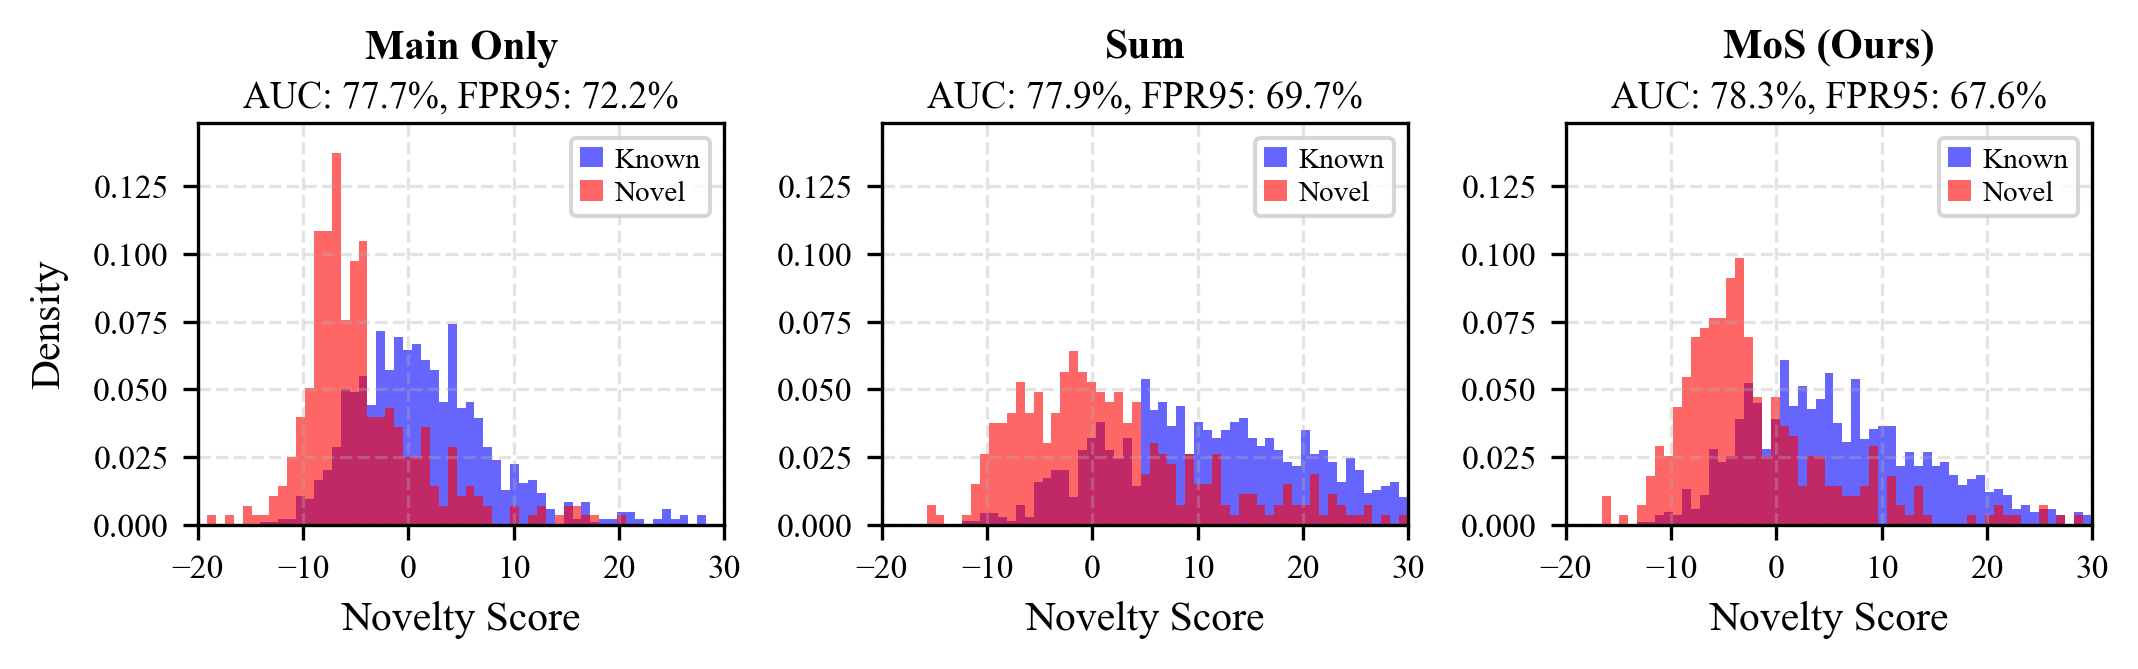

In [9]:
# ===== 셀 4: ID/OOD 분포 시각화 (1×3, 태스크마다 파일 저장) =====
# 공통 x축 [-20, 30], density 히스토그램, Known=blue / Novel=red, AUC·FPR95 서브캡션

plt.rcParams.update({
    'font.family': FONT,
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300,
})
# 축 눈금·범례·AUC/FPR 글자는 위/아래 고정. Novelty/Density 축 제목·방법론 이름만 살짝 작게 (기존 11pt 대비)
FS_AXIS_LABEL = 10
FS_METHOD_NAME = 10
# 방법론명 세로 위치만 조정; AUC/FPR 줄(Y_METRICS_LINE)은 기존과 동일
Y_METHOD_TITLE = 1.14
Y_METRICS_LINE = 1.02  # AUC/FPR: 원래 위치 유지

out_dir = os.path.join(PROJECT_ROOT, 'notebook', 'figures', 'mand_ood_dist', f'inc{INCREMENT}')
os.makedirs(out_dir, exist_ok=True)

X_MIN, X_MAX = -20, 30
bins_shared = np.linspace(X_MIN, X_MAX, 60)
n_col = len(OOD_METHODS)
panel_w = 9.2 / 4
_show_fig = len(TASK_IDS) == 1

for TASK_ID, scores in ALL_SCORES.items():
    base = f'mand_inc{INCREMENT}_task{TASK_ID}_seed{SEED}_1x3'

    fig, axes = plt.subplots(1, n_col, figsize=(panel_w * n_col, 2.35))
    if n_col == 1:
        axes = np.array([axes])

    plot_entries = []
    global_ymax = 0.0

    for i, (display_name, method_key) in enumerate(OOD_METHODS):
        ax = axes[i]
        if display_name not in scores:
            ax.set_axis_off()
            plot_entries.append(None)
            continue
        id_raw = np.asarray(scores[display_name]['id']).ravel()
        ood_raw = np.asarray(scores[display_name]['ood']).ravel()
        id_s = id_raw[(id_raw >= X_MIN) & (id_raw <= X_MAX)]
        ood_s = ood_raw[(ood_raw >= X_MIN) & (ood_raw <= X_MAX)]

        ax.hist(id_s, bins=bins_shared, alpha=0.6, label='Known', color='blue', density=True)
        ax.hist(ood_s, bins=bins_shared, alpha=0.6, label='Novel', color='red', density=True)

        if len(id_s) > 0:
            h_id, _ = np.histogram(id_s, bins=bins_shared, density=True)
            global_ymax = max(global_ymax, float(h_id.max()))
        if len(ood_s) > 0:
            h_ood, _ = np.histogram(ood_s, bins=bins_shared, density=True)
            global_ymax = max(global_ymax, float(h_ood.max()))

        plot_entries.append(display_name)

    for i, name in enumerate(plot_entries):
        if name is None:
            continue
        ax = axes[i]
        m = scores[name]['metrics']
        y_hi = global_ymax * 1.08 if global_ymax > 0 else None
        if y_hi is not None:
            ax.set_ylim(0, y_hi)

        ax.set_xlim(X_MIN, X_MAX)
        ax.legend(loc='upper right', handlelength=0.8, handletextpad=0.4,
                  borderpad=0.3, labelspacing=0.25, prop={'family': FONT, 'size': 7})
        ax.set_xlabel('Novelty Score', fontsize=FS_AXIS_LABEL, fontfamily=FONT)
        if i == 0:
            ax.set_ylabel('Density', labelpad=6, fontsize=FS_AXIS_LABEL, fontfamily=FONT)

        ax.text(
            0.5, Y_METHOD_TITLE, name,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=FS_METHOD_NAME, fontweight='bold', fontfamily=FONT, clip_on=False,
        )
        ax.text(
            0.5, Y_METRICS_LINE, f"AUC: {m['AUROC']:.1f}%, FPR95: {m['FPR95']:.1f}%",
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=9, fontfamily=FONT, clip_on=False,
        )
        ax.grid(axis='both', linestyle='--', alpha=0.35)

    fig.subplots_adjust(left=0.08, right=0.995, top=0.80, bottom=0.23, wspace=0.30)

    out_pdf = os.path.join(out_dir, f'{base}.pdf')
    out_png = os.path.join(out_dir, f'{base}.png')
    plt.savefig(out_pdf, bbox_inches='tight')
    plt.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f'저장됨: {out_pdf}\n        {out_png}')

    if _show_fig:
        plt.show()
    else:
        plt.close(fig)

if not _show_fig:
    print(f'✅ 총 {len(ALL_SCORES)}개 태스크 figure 저장 완료 (배치 모드: plt.show 생략)')


In [10]:
# ===== 셀 5: Table/Fig.3 — CSV + OOD curves (English labels only; avoids font warnings) =====
# Same MAND checkpoints everywhere: compare OOD *scoring* — main-stream MaxLogit vs MoS fused.

paper_dir = os.path.join(
    PROJECT_ROOT, 'notebook', 'figures', 'mand_ood_dist',
    f'inc{INCREMENT}', f'seed{SEED}_paper'
)
os.makedirs(paper_dir, exist_ok=True)
csv_path = os.path.join(paper_dir, f'ood_cl_by_task_inc{INCREMENT}_seed{SEED}.csv')

if not ALL_METRICS_ROWS:
    print('! ALL_METRICS_ROWS empty -- check METRICS_TASK_IDS and cell 3')
else:
    fieldnames = list(ALL_METRICS_ROWS[0].keys())
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(ALL_METRICS_ROWS)
    print(f'Saved: {csv_path}')

    tasks = [r['task_id'] for r in ALL_METRICS_ROWS]
    def col(k):
        return [r.get(k) for r in ALL_METRICS_ROWS]

    plt.rcParams.update({'font.family': FONT, 'figure.dpi': 150})
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4))

    k_main_au = f'{KEY_BASELINE_SCORE}_auroc'
    k_main_fp = f'{KEY_BASELINE_SCORE}_fpr95'
    k_mos_au = f'{KEY_MOS}_auroc'
    k_mos_fp = f'{KEY_MOS}_fpr95'

    lbl_main = 'MaxLogit (main only, same MAND ckpt)'
    lbl_mos = 'MoS fused (same MAND ckpt)'

    ax = axes[0]
    if any(col(k_main_au)):
        ax.plot(tasks, col(k_main_au), 's-', label=lbl_main + ' AUROC', color='#555')
    if any(col(k_mos_au)):
        ax.plot(tasks, col(k_mos_au), 'o-', label=lbl_mos + ' AUROC', color='#c00')
    ax.set_xlabel('Task index')
    ax.set_ylabel('AUROC (%)')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)
    ax.set_title('OOD AUROC vs. task')

    ax = axes[1]
    if any(col(k_main_fp)):
        ax.plot(tasks, col(k_main_fp), 's-', label=lbl_main + ' FPR95', color='#555')
    if any(col(k_mos_fp)):
        ax.plot(tasks, col(k_mos_fp), 'o-', label=lbl_mos + ' FPR95', color='#c00')
    ax.set_xlabel('Task index')
    ax.set_ylabel('FPR95 (%)')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)
    ax.set_title('OOD FPR95 vs. task (lower is better)')

    fig.suptitle(
        'Within MAND: scoring comparison (not a separate CL method)',
        fontsize=9, y=1.02,
    )
    fig.tight_layout()
    p_pdf = os.path.join(paper_dir, f'fig_ood_curves_inc{INCREMENT}_seed{SEED}.pdf')
    p_png = os.path.join(paper_dir, f'fig_ood_curves_inc{INCREMENT}_seed{SEED}.png')
    fig.savefig(p_pdf, bbox_inches='tight')
    fig.savefig(p_png, bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f'Saved curves: {p_pdf}')


✅ 저장: /workspace/MMEA-MoAS/notebook/figures/mand_ood_dist/inc4/seed1997_paper/ood_cl_by_task_inc4_seed1997.csv


/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/936275781.py:59: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_2889045/93

✅ Fig.3 스타일 곡선: /workspace/MMEA-MoAS/notebook/figures/mand_ood_dist/inc4/seed1997_paper/fig_ood_curves_inc4_seed1997.pdf


In [11]:
# ===== 셀 6: Fig.2-style — TWO trained models (optional) =====
# Top:  BASELINE_WEIGHTS_DIR model + MaxLogit on main logits only.
# Bottom: MAND checkpoint + MoS fused score.
# Skipped if BASELINE_WEIGHTS_DIR is None (cell 5 then only shows within-MAND scoring).

if model_baseline is None or not BASELINE_WEIGHTS_DIR:
    print(
        'Cell 6 skipped: set BASELINE_WEIGHTS_DIR in cell 1 and run cell 2.\n'
        'Note: Cell 5 curves use only the MAND model and compare two *scoring* rules; '
        'cell 6 compares two different *trained* checkpoints.'
    )
elif COMPARE_TASK_ID is None:
    print('Cell 6 skipped: COMPARE_TASK_ID is None')
else:
    tid = COMPARE_TASK_ID
    ck_m = os.path.join(WEIGHTS_DIR, f'task_{tid}_checkpoint_{tid}.pkl')
    ck_b = os.path.join(BASELINE_WEIGHTS_DIR, f'task_{tid}_checkpoint_{tid}.pkl')

    b_model_name = getattr(model_baseline, 'args', {}).get('model_name', 'baseline_cl')

    print(f'Baseline CL ({b_model_name}) inference, task {tid}...')
    _, _, sd_b = model_baseline.inference_mode_evaluation(data_manager_baseline, ck_b, tid)
    print(f'MAND inference, task {tid}...')
    _, _, sd_m = model.inference_mode_evaluation(data_manager, ck_m, tid)

    def _get_pair(sd, key):
        if key not in sd:
            return None, None
        s = sd[key]
        a = np.asarray(s.get('id_scores', s.get('id', []))).flatten()
        b = np.asarray(s.get('ood_scores', s.get('ood', []))).flatten()
        return a, b

    id_b, ood_b = _get_pair(sd_b, KEY_BASELINE_SCORE)
    id_m, ood_m = _get_pair(sd_m, KEY_MOS)
    if id_b is None or id_m is None:
        print('! Missing score keys -- check ood_methods / models')
    else:
        allv = np.concatenate([id_b, ood_b, id_m, ood_m])
        lo, hi = np.percentile(allv, [2, 98])
        lo, hi = float(lo), float(hi)
        if lo >= hi:
            lo, hi = -20, 30
        bins = np.linspace(lo, hi, 56)

        title_top = f'{b_model_name}: MaxLogit (main logits only)'
        title_bot = 'MAND: MoS fused score (Ours)'

        fig, axes = plt.subplots(2, 1, figsize=(5.4, 5.0), sharex=True)
        for ax, id_s, ood_s, title in [
            (axes[0], id_b, ood_b, title_top),
            (axes[1], id_m, ood_m, title_bot),
        ]:
            id_s = id_s[(id_s >= lo) & (id_s <= hi)]
            ood_s = ood_s[(ood_s >= lo) & (ood_s <= hi)]
            ax.hist(id_s, bins=bins, alpha=0.55, label='Known (ID)', color='blue', density=True)
            ax.hist(ood_s, bins=bins, alpha=0.55, label='Novel (OOD)', color='red', density=True)
            ax.set_ylabel('Density')
            ax.legend(fontsize=7)
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
        axes[1].set_xlabel('Score (MaxLogit; higher = more ID-like)')
        fig.suptitle(
            f'Two trained models | task {tid} | seed {SEED} | inc {INCREMENT}',
            y=1.01, fontsize=9,
        )
        fig.tight_layout()

        paper_dir = os.path.join(
            PROJECT_ROOT, 'notebook', 'figures', 'mand_ood_dist',
            f'inc{INCREMENT}', f'seed{SEED}_paper'
        )
        os.makedirs(paper_dir, exist_ok=True)
        base = f'fig_two_ckpt_maxlogit_vs_mos_task{tid}_seed{SEED}_inc{INCREMENT}'
        fpdf = os.path.join(paper_dir, base + '.pdf')
        fpng = os.path.join(paper_dir, base + '.png')
        fig.savefig(fpdf, bbox_inches='tight')
        fig.savefig(fpng, bbox_inches='tight', dpi=300)
        plt.close(fig)
        print(f'Saved two-checkpoint figure: {fpdf}')


셀 6 스킵: 셀 1에서 BASELINE_WEIGHTS_DIR 설정 + 셀 2 실행


In [12]:
# ===== 셀 7: Strong case — 모달리티별 MaxLogit vs MoS (Known 세트에서 후보 샘플) =====
# RGB는 약하지만 Gyro/Acce는 ID 신호가 강하고, MoS가 main-only보다 ID 쪽으로 당기는 인덱스를 표로 출력

from ood.methods.unified_ood_detector import UnifiedOODDetector
import torch.nn.functional as F

if COMPARE_TASK_ID is None:
    print('셀 7 스킵: COMPARE_TASK_ID 없음')
else:
    tid = COMPARE_TASK_ID
    ck_m = os.path.join(WEIGHTS_DIR, f'task_{tid}_checkpoint_{tid}.pkl')
    model.inference_mode_evaluation(data_manager, ck_m, tid)

    out = model._collect_outputs(model.test_loader)
    if out is None or 'auxiliary_logits' not in out:
        print('⚠️  auxiliary_logits 없음 — MAND fusion·헤드 확인')
    else:
        dev = model._device
        logits = out['logits'].to(dev)
        aux = {k: v.to(dev) for k, v in out['auxiliary_logits'].items()}
        confs = out.get('confidences') or {}
        confs = {k: v.to(dev) for k, v in confs.items()}

        def maxlogit(z):
            return z.max(dim=1).values.detach().cpu().numpy()

        main_sc = maxlogit(logits)
        mod_sc = {m: maxlogit(aux[m]) for m in aux}

        det_mos = UnifiedOODDetector.from_method_name(model._network, KEY_MOS, device=dev)
        pack = {'logits': logits, 'auxiliary_logits': aux, 'confidences': confs}
        mos_sc = det_mos.compute_scores_from_outputs(pack)
        mos_sc = np.asarray(mos_sc).ravel()

        n = len(main_sc)
        rgb = mod_sc.get('RGB', main_sc)
        gyro = mod_sc.get('Gyro', main_sc)
        acce = mod_sc.get('Acce', main_sc)

        # MoS가 main 대비 얼마나 "더 ID 쪽"(maxlogit↑)인지, Gyro가 RGB보다 얼마나 ID 신호가 강한지
        gain_mos = mos_sc - main_sc
        gain_gy_v_rgb = gyro - rgb

        # 후보: Known(test)에서 Gyro가 RGB보다 충분히 크고, MoS가 main을 끌어올림
        idx = np.arange(n)
        mask = (gain_gy_v_rgb > np.percentile(gain_gy_v_rgb, 70)) & (gain_mos > 0)
        order = idx[mask][np.argsort(-gain_mos[mask])[:15]]

        paper_dir = os.path.join(
            PROJECT_ROOT, 'notebook', 'figures', 'mand_ood_dist',
            f'inc{INCREMENT}', f'seed{SEED}_paper'
        )
        os.makedirs(paper_dir, exist_ok=True)
        tpath = os.path.join(paper_dir, f'strong_case_candidates_task{tid}_seed{SEED}.csv')

        with open(tpath, 'w', newline='', encoding='utf-8') as f:
            w = csv.writer(f)
            w.writerow(['idx', 'main_maxlogit', 'rgb_maxlogit', 'gyro_maxlogit', 'acce_maxlogit', 'mos_fused', 'mos_minus_main', 'gyro_minus_rgb'])
            for i in order:
                w.writerow([
                    int(i), float(main_sc[i]), float(rgb[i]), float(gyro[i]), float(acce[i]),
                    float(mos_sc[i]), float(gain_mos[i]), float(gain_gy_v_rgb[i]),
                ])
        print(f'✅ Strong case 후보 표 (Known test 상위): {tpath}')
        print('   해석: gyro_minus_rgb↑ & mos_minus_main↑ 이면 IMU가 RGB보다 ID 신호가 강하고 MoS가 main보다 덜 novel로 밀리는 샘플.')

        # 미니 스캐터: RGB vs Gyro maxlogit (표현만)
        plt.figure(figsize=(3.8, 3.6))
        plt.scatter(rgb, gyro, s=6, alpha=0.35, c='gray', label='all')
        plt.scatter(rgb[order[:5]], gyro[order[:5]], s=22, c='red', label='top5 candidates')
        plt.xlabel('RGB max logit')
        plt.ylabel('Gyro max logit')
        plt.legend(fontsize=7)
        plt.title(f'Known: RGB vs Gyro (task {tid})')
        plt.grid(True, alpha=0.3)
        sp = os.path.join(paper_dir, f'strong_case_rgb_vs_gyro_task{tid}.png')
        plt.savefig(sp, dpi=200, bbox_inches='tight')
        plt.close()
        print(f'✅ 스캐터: {sp}')


🔍 TBNClassification Debug:
   Modality count: 3
   Feature dim: 512
   FC input dim: 512
   FC output dim: 24


RuntimeError: The expanded size of the tensor (24) must match the existing size (28) at non-singleton dimension 0.  Target sizes: [24, 512].  Tensor sizes: [28, 512]